# Sales forecasting for the coming 6 months — Technical Notebook

## 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime , timedelta

## 2. Load Data


In [3]:
# Load the raw dataset exported from the source system
df = pd.read_csv(r'**************************************')

## 3. Initial Exploration


In [4]:
#df.describe()

In [5]:
#print(df.dtypes)

## 4. Data Cleaning & Feature Engineering


In [6]:
# Transforming data to the correct Data types
df = df.drop_duplicates()
df['DayDate'] = pd.to_datetime(df['DayDate'])
df['winning_date'] = pd.to_datetime(df['DeliveryDate'])
df['travel_date'] = pd.to_datetime(df['DeliveryDate2'])
df['DeliveryDate2'] = pd.to_datetime(df['DeliveryDate2'])
df['travel_status'] = df['DeliveryDate2'].apply(lambda x: "travelled" if x > pd.Timestamp('1900-01-01') else "not_travelled")
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])
df['winning_status'] = df['DeliveryDate'].apply(lambda x: "winner" if x > pd.Timestamp('1900-01-01') else "not_winner")
df['total_arears'] = df['قيمة المتأخرات - فائز'] + df['قيمة المتأخرات - غير فائز']
df['pay_status'] = df['عدد متأخر - غير فائز'] + df['عدد متأخر - فائز']
df['customer_status'] = df['عدد سحب غير فائز'] + df['عدد سحب فائز']
df['refund_amount'] = df['قيمة سداد السحب غير فائز'] + df['قيمة سداد السحب فائز']

In [7]:
# drop unnecessery Columns
df_clean = df[['اسم الفرع', 'DayDate',
       'عدد الربط', 'عدد الفردي', 'عدد الربط - صافي', 'عدد الفردي - صافي',
       'قيمة السداد الفردي - صافي','كود العميل','اسم العميل','عدد الأقساط',
      'total_arears', 'pay_status', 'customer_status', 'refund_amount',
       'winning_date', 'travel_date','winning_status', 'travel_status']]



In [8]:
df_clean['customer_status'] = df_clean['customer_status'].apply(lambda x: "active" if x == 1 else "lost")
df_clean['pay_status'] = df_clean['pay_status'].apply(lambda x: "delay" if x == 1 else "committed")
df_clean['customer_type'] = df_clean['عدد الفردي'].apply(lambda x: "sinle" if x == 1 else "group")
df_clean.drop(columns= 'قيمة السداد الفردي - صافي',inplace=True)


In [9]:
df_clean['branch_name'] = df_clean['اسم الفرع']
df_clean['customer_name'] = df_clean['اسم العميل']
df_clean['customer_code'] = df_clean['كود العميل']
df_clean['instal_amount'] = df['قيمة القسط']
df_clean['instal_count'] = df_clean['عدد الأقساط']
df_clean['total_paid'] = df['إجمالي قيمة السداد']
df_clean['week_number'] = df['DayDate'].dt.isocalendar().week
df_clean['year'] = df['DayDate'].dt.isocalendar().year
df_clean['year_week'] = df_clean['year'].astype(str) + df_clean['week_number'].astype(str).str.zfill(2)

In [10]:
df_clean.drop(columns= ['اسم الفرع', 'اسم العميل', 'عدد الأقساط','عدد الربط - صافي','عدد الفردي - صافي','customer_name'],inplace=True)
df_clean['month'] = df_clean['DayDate'].dt.strftime('%b')

In [ ]:
df_clean.sample(10)

## 5. Select Relevant Columns


In [12]:
customer_count = df_clean.groupby('year_week').size()
customer_count
df_forecast = df_clean[['year','year_week','month','week_number']]
df_forecast['customer_counts'] = df_forecast['year_week'].map(customer_count)
df_forecast

,year,year_week,month,week_number,customer_counts
0,2024,202415,Apr,15,33
1,2024,202414,Apr,14,89
2,2024,202417,Apr,17,95
3,2024,202417,Apr,17,95
4,2024,202417,Apr,17,95
...,...,...,...,...,...
20909,2026,202605,Feb,5,232
20910,2026,202602,Jan,2,478
20911,2026,202616,Apr,16,355
20912,2026,202617,Apr,17,658


In [13]:
df_forecast['lag_1'] = df_forecast['customer_counts'].shift(1).dropna() # last week
df_forecast['lag_2'] = df_forecast['customer_counts'].shift(2).dropna()  # the week before

## 6.Encode months

In [14]:
df_dummies = pd.get_dummies(df_forecast['month'],drop_first=True).astype(int)
df_forecast = pd.concat([df_forecast, df_dummies], axis=1).dropna()
df_forecast.drop(columns='month',inplace=True)
df_forecast

,year,year_week,week_number,customer_counts,lag_1,lag_2,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
2,2024,202417,17,95,89.0,33.0,0,0,0,0,0,0,0,0,0,0,0
3,2024,202417,17,95,95.0,89.0,0,0,0,0,0,0,0,0,0,0,0
4,2024,202417,17,95,95.0,95.0,0,0,0,0,0,0,0,0,0,0,0
5,2024,202418,18,204,95.0,95.0,0,0,0,0,0,0,0,0,0,0,0
6,2024,202418,18,204,204.0,95.0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2026,202605,5,232,472.0,232.0,0,0,1,0,0,0,0,0,0,0,0
20910,2026,202602,2,478,232.0,472.0,0,0,0,1,0,0,0,0,0,0,0
20911,2026,202616,16,355,478.0,232.0,0,0,0,0,0,0,0,0,0,0,0
20912,2026,202617,17,658,355.0,478.0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
df_forecast = df_forecast.dropna()

## 7. Train / Test Split


In [16]:
x= df_forecast.drop(columns= ['customer_counts','week_number','year_week', 'Dec', 'May'])
y = df_forecast['customer_counts']
x = x.loc[:, ~x.columns.duplicated()]
y = y.astype(float)
x = x.astype(float)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [17]:
print(x.columns.tolist())

['year', 'lag_1', 'lag_2', 'Aug', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'Nov', 'Oct', 'Sep']


In [18]:
x= sm.add_constant(x)


## 8. Train Linear Regression Model


In [19]:
model = sm.OLS(y, x)
result = model.fit()

In [20]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        customer_counts   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     3993.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:39:21   Log-Likelihood:            -1.2231e+05
No. Observations:               20912   AIC:                         2.446e+05
Df Residuals:                   20899   BIC:                         2.447e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.467e+05   1777.983    -82.511      0.000    -1.5e+05   -1.43e+05
year          72.5337      0.878     82.575      0.000      70.812      74.255
lag_1          0.3795      0.006     62.621      0.000       0.368       0.391
lag_2          0.0564      0.006     10.117      0.000       0.046       0.067
Aug          -10.4079      2.327     -4.473      0.000     -14.969      -5.847
Feb         -132.6874      2.530    -52.438      0.000    -137.647    -127.728
Jan          -38.3905      1.924    -19.950      0.000     -42.162     -34.619
Jul          -68.1895      2.639    -25.842      0.000     -73.362     -63.018
Jun          -93.6392      2.939    -31.856      0.000     -99.401     -87.878
Mar         -183.6472      3.393    -54.121      0.000    -190.298    -176.996
Nov           17.7158      2.028      8.734      0.000      13.740      21.691
Oct          -55.2882      2.462    -22.452      0.000     -60.115     -50.462
Sep          -79.5482      2.700    -29.463      0.000     -84.840     -74.256
==============================================================================
Omnibus:                     1076.737   Durbin-Watson:                   1.740
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4218.903
Skew:                          -0.004   Prob(JB):                         0.00
Kurtosis:                       5.200   Cond. No.                     6.28e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.28e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Evaluating the model

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = result.predict(x)

x_test_const = sm.add_constant(x_test, has_constant='add')
y_pred = result.predict(x_test_const)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")
print(f"MAPE: {mape:.2f}%")


MAE:  62.87
RMSE: 85.23
R²:   0.684
MAPE: 49.37%


## 9.Next 6 months customer counts predictions

### AI Generated for code optimazing

### 1.building Time Table for the next 6 months

In [22]:
future_dates = pd.date_range(
    start=df['DayDate'].max() + pd.Timedelta(weeks=1), 
    periods=26, freq='W')

future_df = pd.DataFrame({'date': future_dates})
future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month_name().str[:3]

# adding months
for m in ['Aug','Feb','Jan','Jul','Jun','Mar','Nov','Oct','Sep']:
    future_df[m] = (future_df['month'] == m).astype(int)



In [23]:
print(result.params.index)

Index(['const', 'year', 'lag_1', 'lag_2', 'Aug', 'Feb', 'Jan', 'Jul', 'Jun',
       'Mar', 'Nov', 'Oct', 'Sep'],
      dtype='str')


### 2.Forecasting the data

In [ ]:
lag1 = df_forecast['customer_counts'].iloc[-1]
lag2 = df_forecast['customer_counts'].iloc[-2]
preds = []

for _, row in future_df.iterrows():
    x = [1, row['year'], lag1, lag2, row['Aug'], row['Feb'], row['Jan'], 
         row['Jul'], row['Jun'], row['Mar'], row['Nov'], row['Oct'], row['Sep']]
    
    pred = round(result.params @ x)
    preds.append(pred)
    lag2, lag1 = lag1, pred

future_df['forecast'] = preds
print(future_df[['date','month','forecast']])
future_df.to_csv('forecasting 2026.csv', index=False)

         date month  forecast
0  2026-05-24   May       493
1  2026-05-31   May       468
2  2026-06-07   Jun       362
3  2026-06-14   Jun       321
4  2026-06-21   Jun       299
5  2026-06-28   Jun       289
6  2026-07-05   Jul       309
7  2026-07-12   Jul       316
8  2026-07-19   Jul       320
9  2026-07-26   Jul       322
10 2026-08-02   Aug       380
11 2026-08-09   Aug       403
12 2026-08-16   Aug       415
13 2026-08-23   Aug       420
14 2026-08-30   Aug       423
15 2026-09-06   Sep       355
16 2026-09-13   Sep       330
17 2026-09-20   Sep       316
18 2026-09-27   Sep       310
19 2026-10-04   Oct       331
20 2026-10-11   Oct       338
21 2026-10-18   Oct       342
22 2026-10-25   Oct       344
23 2026-11-01   Nov       418
24 2026-11-08   Nov       446
25 2026-11-15   Nov       461


## 3.ploting weekly Expected performance

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_style("darkgrid", {
    "axes.facecolor": "#121212",
    "figure.facecolor": "#121212",
    "grid.color": "#262626"
})

plt.figure(figsize=(18, 6))

sns.lineplot(data=Weekly_performance, x='date', y='forecast', marker='o', color='#3b82f6', linewidth=2.5)

for _, row in Weekly_performance.iterrows():
    plt.text(
        row['date'], 
        row['forecast'] + 8, 
        str(int(row['forecast'])), 
        ha='center', 
        fontsize=10, 
        color='#60a5fa',  
        weight='bold'
    )

plt.xticks(ticks=Weekly_performance['date'], 
           labels=Weekly_performance['date'].dt.strftime('%Y-%m-%d'), 
           rotation=90, 
           ha='right',
           color='white')

plt.yticks(color='white')
plt.title('6 Months Predictions', fontsize=14, pad=15, weight='bold', color='white')
plt.xlabel('Date', fontsize=12, labelpad=10, color='white')
plt.ylabel('Forecasted Value', fontsize=12, labelpad=10, color='white')

plt.tight_layout()
plt.show()

### 4.Ploting the upcoming months

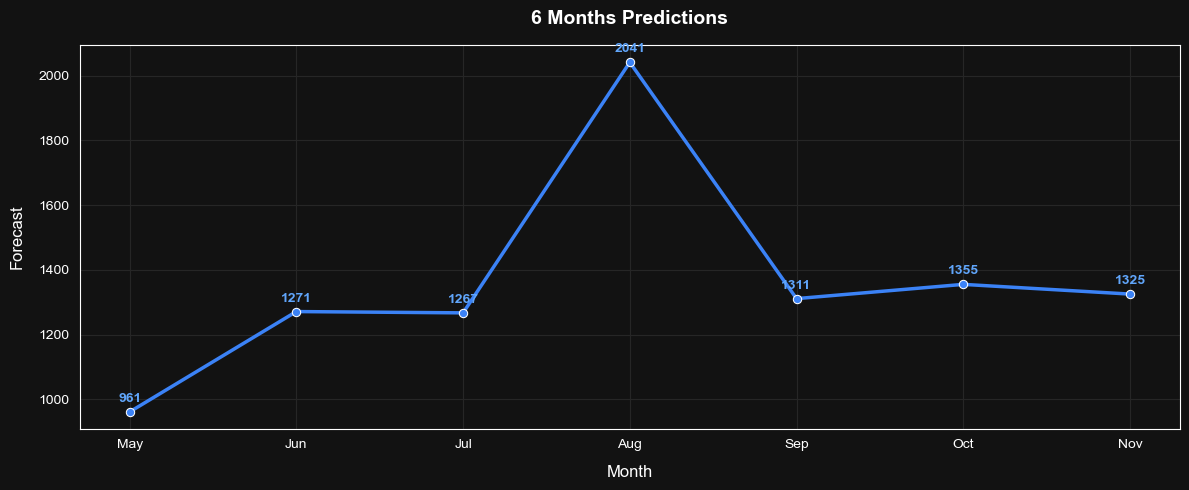

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

month_order = ['May','Jun','Jul','Aug','Sep','Oct','Nov']

prediction_table = (
    future_df.groupby('month', sort=False)['forecast']
    .sum()
    .reindex(month_order)
    .reset_index(name='forecast')
)

plt.style.use("dark_background")
sns.set_style("darkgrid", {
    "axes.facecolor": "#121212",
    "figure.facecolor": "#121212",
    "grid.color": "#262626"
})

plt.figure(figsize=(12, 5))

sns.lineplot(data=prediction_table, x='month', y='forecast', marker='o', color='#3b82f6', linewidth=2.5)

offset = prediction_table['forecast'].max() * 0.015

for _, row in prediction_table.iterrows():
    plt.text(row['month'], row['forecast'] + offset, 
             str(int(row['forecast'])), 
             ha='center', fontsize=10, color='#60a5fa', weight='bold')

plt.xticks(color='white')
plt.yticks(color='white')
plt.title('6 Months Predictions', fontsize=14, pad=15, weight='bold', color='white')
plt.xlabel('Month', fontsize=12, labelpad=10, color='white')
plt.ylabel('Forecast', fontsize=12, labelpad=10, color='white')

plt.tight_layout()
plt.show()

# Predicting with lower bound and higher bound 
## with 95% Confidence Interval
## AI Generated for code optimazing

In [ ]:

lag1 = df_forecast['customer_counts'].iloc[-1]
lag2 = df_forecast['customer_counts'].iloc[-2]

preds = []
se_obs_list = [] 

for _, row in future_df.iterrows():
   
    x_vals = [1, row['year'], lag1, lag2, row['Aug'], row['Feb'], row['Jan'], 
              row['Jul'], row['Jun'], row['Mar'], row['Nov'], row['Oct'], row['Sep']]
    
    x_df = pd.DataFrame([x_vals], columns=result.params.index)
    
    pred_obj = result.get_prediction(x_df)
    pred_summary = pred_obj.summary_frame(alpha=0.05) 
    
    pred_val = pred_summary['mean'].values[0]
    se_obs = pred_obj.se_obs[0] 
    
    preds.append(round(pred_val))
    se_obs_list.append(se_obs)
    
    lag2, lag1 = lag1, round(pred_val)

future_df['forecast'] = preds
future_df['se_obs'] = se_obs_list
future_df

,date,year,month,Aug,Feb,Jan,Jul,Jun,Mar,Nov,Oct,Sep,forecast,se_obs
0,2026-05-24,2026,May,0,0,0,0,0,0,0,0,0,493,83.955248
1,2026-05-31,2026,May,0,0,0,0,0,0,0,0,0,468,83.948557
2,2026-06-07,2026,Jun,0,0,0,0,1,0,0,0,0,362,83.993022
3,2026-06-14,2026,Jun,0,0,0,0,1,0,0,0,0,321,83.991520
4,2026-06-21,2026,Jun,0,0,0,0,1,0,0,0,0,299,83.988182
5,2026-06-28,2026,Jun,0,0,0,0,1,0,0,0,0,289,83.987669
6,2026-07-05,2026,Jul,0,0,0,1,0,0,0,0,0,309,83.975987
7,2026-07-12,2026,Jul,0,0,0,1,0,0,0,0,0,316,83.975952
8,2026-07-19,2026,Jul,0,0,0,1,0,0,0,0,0,320,83.975983
9,2026-07-26,2026,Jul,0,0,0,1,0,0,0,0,0,322,83.976022


--- Monthly Forecast with 95% Confidence Intervals ---
  month  lower_bound  forecast  upper_bound
0   May        728.0       961       1194.0
1   Jun        942.0      1271       1600.0
2   Jul        938.0      1267       1596.0
3   Aug       1673.0      2041       2409.0
4   Sep        982.0      1311       1640.0
5   Oct       1026.0      1355       1684.0
6   Nov       1040.0      1325       1610.0
------------------------------------------------------


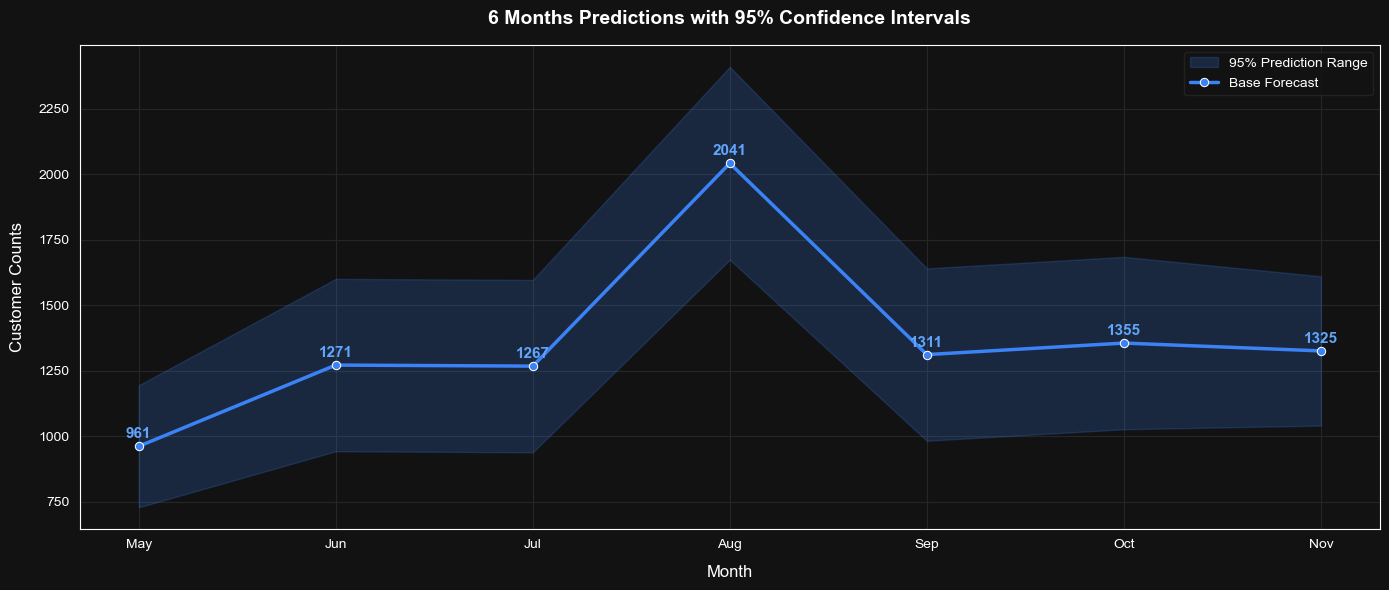

In [ ]:
month_order = ['May','Jun','Jul','Aug','Sep','Oct','Nov']

monthly_stats = future_df.groupby('month', sort=False).agg(
    forecast=('forecast', 'sum'),
    variance=('se_obs', lambda x: np.sum(x**2))
).reindex(month_order).reset_index()

z_score = 1.96 
monthly_stats['lower_bound'] = np.maximum(0, np.round(monthly_stats['forecast'] - z_score * np.sqrt(monthly_stats['variance'])))
monthly_stats['upper_bound'] = np.round(monthly_stats['forecast'] + z_score * np.sqrt(monthly_stats['variance']))

print("--- Monthly Forecast with 95% Confidence Intervals ---")
print(monthly_stats[['month', 'lower_bound', 'forecast', 'upper_bound']])
print("-" * 54)

plt.style.use("dark_background")
sns.set_style("darkgrid", {
    "axes.facecolor": "#121212",
    "figure.facecolor": "#121212",
    "grid.color": "#262626"
})

plt.figure(figsize=(14, 6))

plt.fill_between(monthly_stats['month'], 
                 monthly_stats['lower_bound'], 
                 monthly_stats['upper_bound'], 
                 color='#3b82f6', alpha=0.2, label='95% Prediction Range')

sns.lineplot(data=monthly_stats, x='month', y='forecast', marker='o', color='#3b82f6', linewidth=2.5, label='Base Forecast')

offset = monthly_stats['forecast'].max() * 0.015

for _, row in monthly_stats.iterrows():
    plt.text(row['month'], row['forecast'] + offset, 
             str(int(row['forecast'])), 
             ha='center', fontsize=11, color='#60a5fa', weight='bold')

plt.xticks(color='white')
plt.yticks(color='white')
plt.title('6 Months Predictions with 95% Confidence Intervals', fontsize=14, pad=15, weight='bold', color='white')
plt.xlabel('Month', fontsize=12, labelpad=10, color='white')
plt.ylabel('Customer Counts', fontsize=12, labelpad=10, color='white')
legend = plt.legend(facecolor='#121212', edgecolor='#262626')
if legend:
    for text in legend.get_texts():
        text.set_color('white')

plt.tight_layout()
plt.show()

### Export the Weakly predictions

In [ ]:

z_score = 1.96
future_df['lower_bound'] = np.maximum(0, np.round(future_df['forecast'] - z_score * future_df['se_obs']))
future_df['upper_bound'] = np.round(future_df['forecast'] + z_score * future_df['se_obs'])

weekly_export = future_df[['date', 'lower_bound', 'forecast', 'upper_bound']]

weekly_export.to_csv('weekly_forecast_intervals.csv', index=False)

print("--- Weekly Forecast with 95% Confidence Intervals ---")
print(weekly_export.head())

,date,year,month,Aug,Feb,Jan,Jul,Jun,Mar,Nov,Oct,Sep,forecast,se_obs
0,2026-05-24,2026,May,0,0,0,0,0,0,0,0,0,493,83.955248
1,2026-05-31,2026,May,0,0,0,0,0,0,0,0,0,468,83.948557
2,2026-06-07,2026,Jun,0,0,0,0,1,0,0,0,0,362,83.993022
3,2026-06-14,2026,Jun,0,0,0,0,1,0,0,0,0,321,83.991520
4,2026-06-21,2026,Jun,0,0,0,0,1,0,0,0,0,299,83.988182
5,2026-06-28,2026,Jun,0,0,0,0,1,0,0,0,0,289,83.987669
6,2026-07-05,2026,Jul,0,0,0,1,0,0,0,0,0,309,83.975987
7,2026-07-12,2026,Jul,0,0,0,1,0,0,0,0,0,316,83.975952
8,2026-07-19,2026,Jul,0,0,0,1,0,0,0,0,0,320,83.975983
9,2026-07-26,2026,Jul,0,0,0,1,0,0,0,0,0,322,83.976022
